In [1]:
import sys, os

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.join(os.path.abspath('..'), 'config'))
from setup_env import setup

PROJECT_ROOT, DATA_DIR, DEVICE = setup()
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'DATA_DIR     = {DATA_DIR}')
print(f'DEVICE       = {DEVICE}')


In [ ]:
import os, glob, random
from datetime import date
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

#  Hyperparameters
MODALITY    = 'ct_256'    # 'ct_256' or 'mr_256'
NUM_CLASSES = 8
BATCH_SIZE  = 20
LR          = 1e-4
EPOCHS      = 30
LOSS        = 'combined'  # same as ResU-Net for fair encoder comparison
EARLY_STOP_PATIENCE = 10
CLAHE_CLIP  = 0.3
# best_{encoder}_{modality}_{loss}_{date}
CKPT_NAME   = f'best_efficientnet_ct_combined_loss_{date.today()}.pth'

#  Quick test mode
QUICK_TEST      = False
MAX_TRAIN_FILES = 300 if QUICK_TEST else None
QUICK_EPOCHS    = 15  if QUICK_TEST else EPOCHS

CLASS_NAMES = {0:'BG', 1:'MYO', 2:'LA', 3:'LV', 4:'RA', 5:'RV', 6:'AA', 7:'PA'}

print(f'Device:     {DEVICE}')
print(f'Modality:   {MODALITY}')
print(f'Loss:       {LOSS}')
print(f'Epochs:     {QUICK_EPOCHS}')
print(f'Checkpoint: {CKPT_NAME}')

Device:     cuda
Modality:   ct_256
Loss:       combined
Epochs:     30
Checkpoint: best_efficientnet_ct_combined_loss_2026-03-31.pth


In [3]:
from src.dataset import MMWHSDataset
from src.losses  import compute_weights, get_loss
from src.metrics import dice_binary, jaccard, surface_distances

In [4]:
#  Dataset
train_ds = MMWHSDataset(MODALITY, 'train', DATA_DIR, augment=True,  max_files=MAX_TRAIN_FILES, clahe_clip=CLAHE_CLIP)
val_ds   = MMWHSDataset(MODALITY, 'val',   DATA_DIR, augment=False, clahe_clip=CLAHE_CLIP)
test_ds  = MMWHSDataset(MODALITY, 'test',  DATA_DIR, augment=False, clahe_clip=CLAHE_CLIP)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

Train: 3389  Val: 382  Test: 484


In [5]:
#  Model - EfficientNet-B4 encoder, same decoder setup as ResU-Net for fair comparison
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name           = 'efficientnet-b4',  # EfficientNet-B4 encoder
    encoder_weights        = 'imagenet',          # ImageNet pretrained
    in_channels            = 1,
    classes                = NUM_CLASSES,
    decoder_attention_type = 'scse',              # same as ResU-Net
    decoder_dropout        = 0.2,                 # same as ResU-Net
).to(DEVICE)
model.segmentation_head.add_module('dropout', nn.Dropout2d(p=0.15))  # same as ResU-Net

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Encoder:    EfficientNet-B4 (ImageNet pretrained)')
print(f'Attention:  scSE')
print(f'Seg head:   Dropout2d(p=0.15)')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Parameters: 20,303,269
Encoder:    EfficientNet-B4 (ImageNet pretrained)
Attention:  scSE
Seg head:   Dropout2d(p=0.15)


In [6]:
#  Loss
print('Computing class weights...')
weights   = compute_weights(DATA_DIR, MODALITY, NUM_CLASSES, DEVICE)
criterion = get_loss(LOSS, weights, NUM_CLASSES)

print('Class weights:')
for i, w in enumerate(weights.cpu().numpy()):
    print(f'  {CLASS_NAMES[i]:<4}: {w:.4f}')

Computing class weights...
Class weights:
  BG  : 0.0209
  MYO : 0.8192
  LA  : 1.1968
  LV  : 1.0662
  RA  : 1.1925
  RV  : 0.7955
  AA  : 1.4856
  PA  : 1.4233


Epoch   1/30  train=1.2659  val=1.0337  lr=1.00e-04  patience=0
Epoch   2/30  train=0.7004  val=0.7129  lr=1.00e-04  patience=0
Epoch   3/30  train=0.4668  val=0.5288  lr=1.00e-04  patience=0
Epoch   4/30  train=0.3808  val=0.4393  lr=1.00e-04  patience=0
Epoch   5/30  train=0.3252  val=0.4068  lr=1.00e-04  patience=0


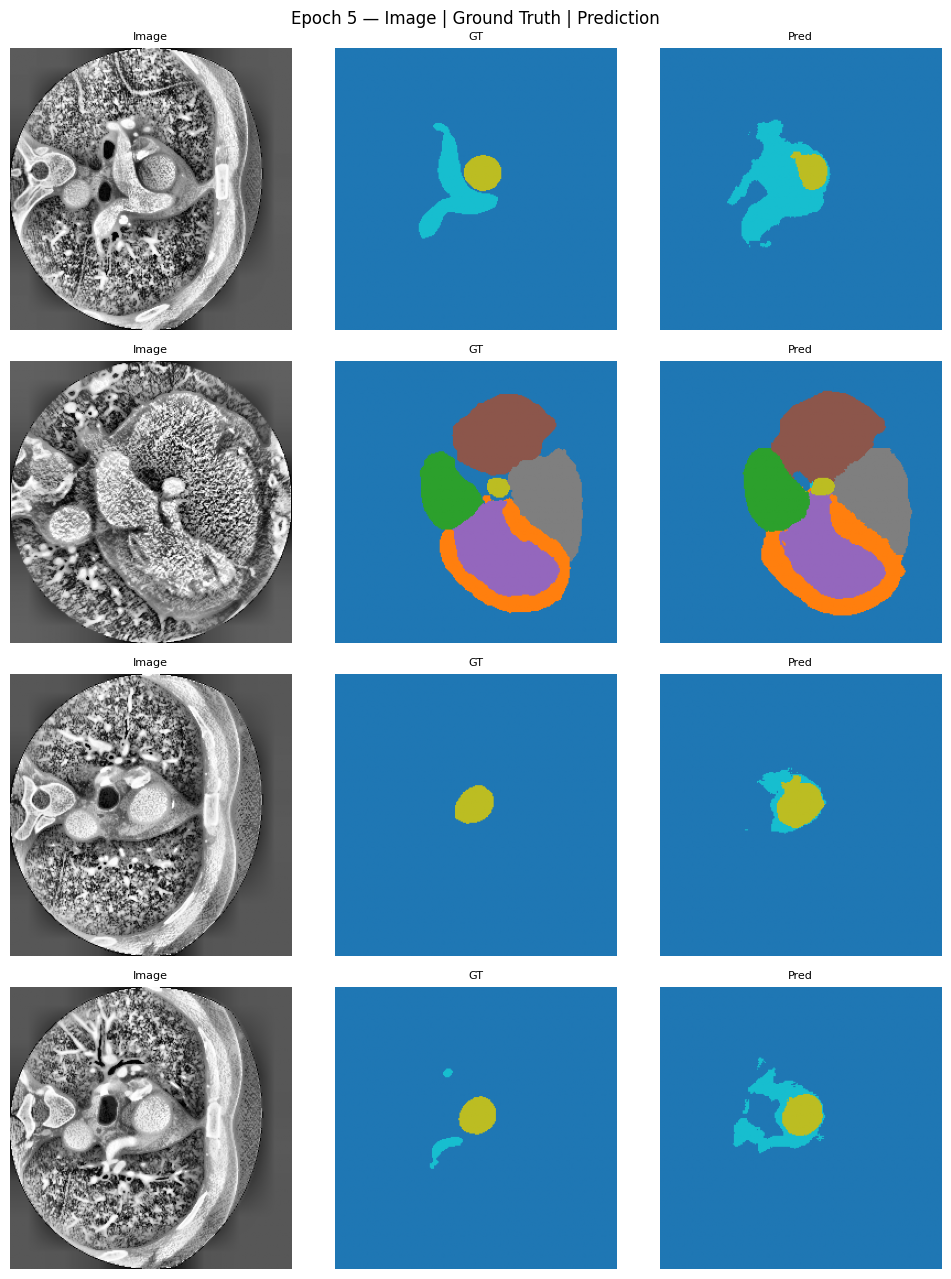


  Epoch 5 — Dice:
    MYO : 0.8182
    LA  : 0.8437
    LV  : 0.7945
    RA  : 0.7663
    RV  : 0.7793
    AA  : 0.8883
    PA  : 0.4874
    Mean: 0.7682

Epoch   6/30  train=0.2984  val=0.3772  lr=1.00e-04  patience=0
Epoch   7/30  train=0.2860  val=0.3935  lr=1.00e-04  patience=1
Epoch   8/30  train=0.2771  val=0.4155  lr=1.00e-04  patience=2
Epoch   9/30  train=0.2722  val=0.3995  lr=1.00e-04  patience=3
Epoch  10/30  train=0.2550  val=0.3893  lr=1.00e-04  patience=4


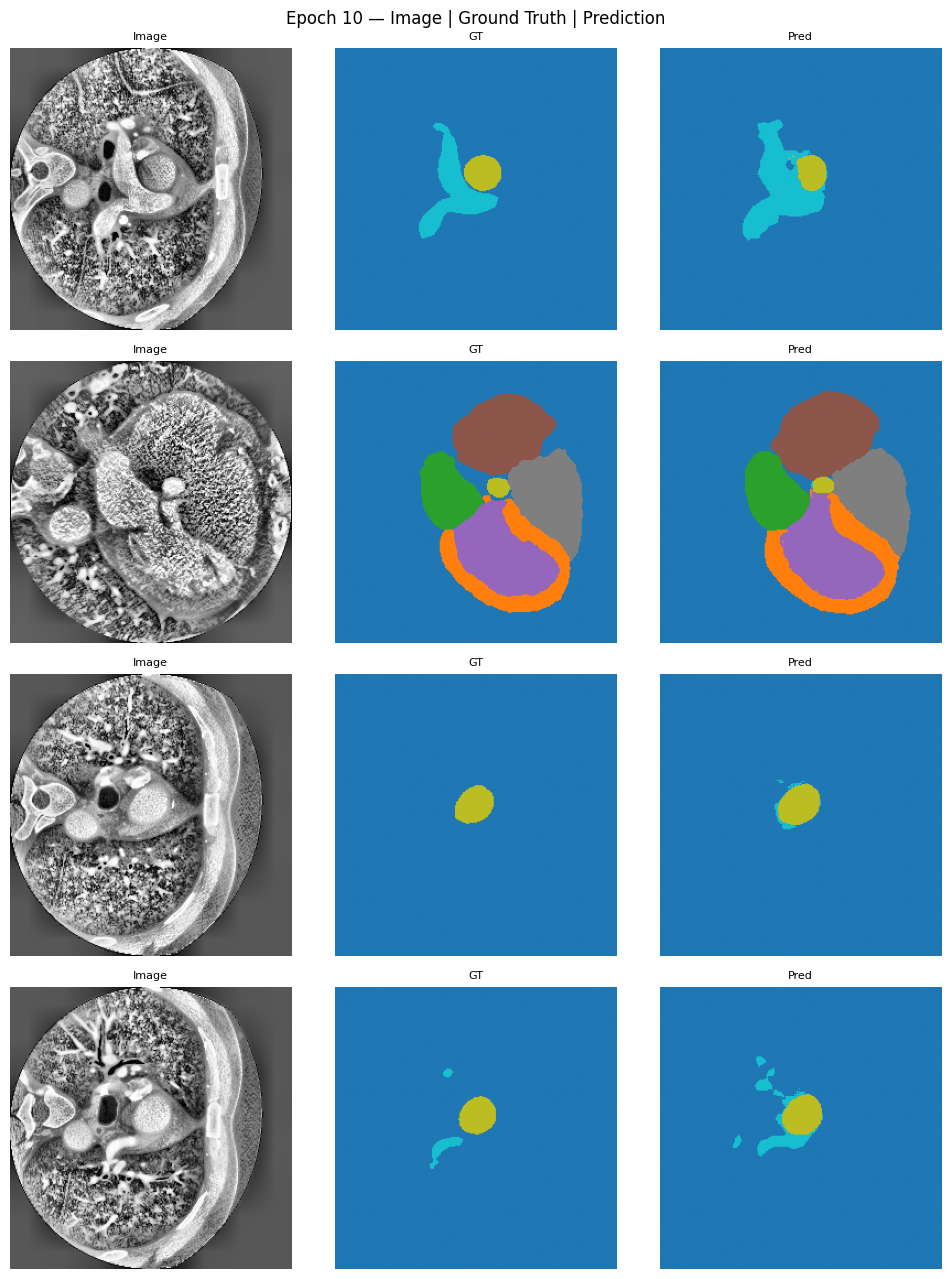


  Epoch 10 — Dice:
    MYO : 0.8420
    LA  : 0.8868
    LV  : 0.8294
    RA  : 0.7949
    RV  : 0.8140
    AA  : 0.9007
    PA  : 0.6276
    Mean: 0.8136

Epoch  11/30  train=0.2536  val=0.3969  lr=1.00e-04  patience=5
Epoch  12/30  train=0.2504  val=0.3811  lr=5.00e-05  patience=6
Epoch  13/30  train=0.2447  val=0.3841  lr=5.00e-05  patience=7
Epoch  14/30  train=0.2433  val=0.3901  lr=5.00e-05  patience=8
Epoch  15/30  train=0.2420  val=0.4090  lr=5.00e-05  patience=9


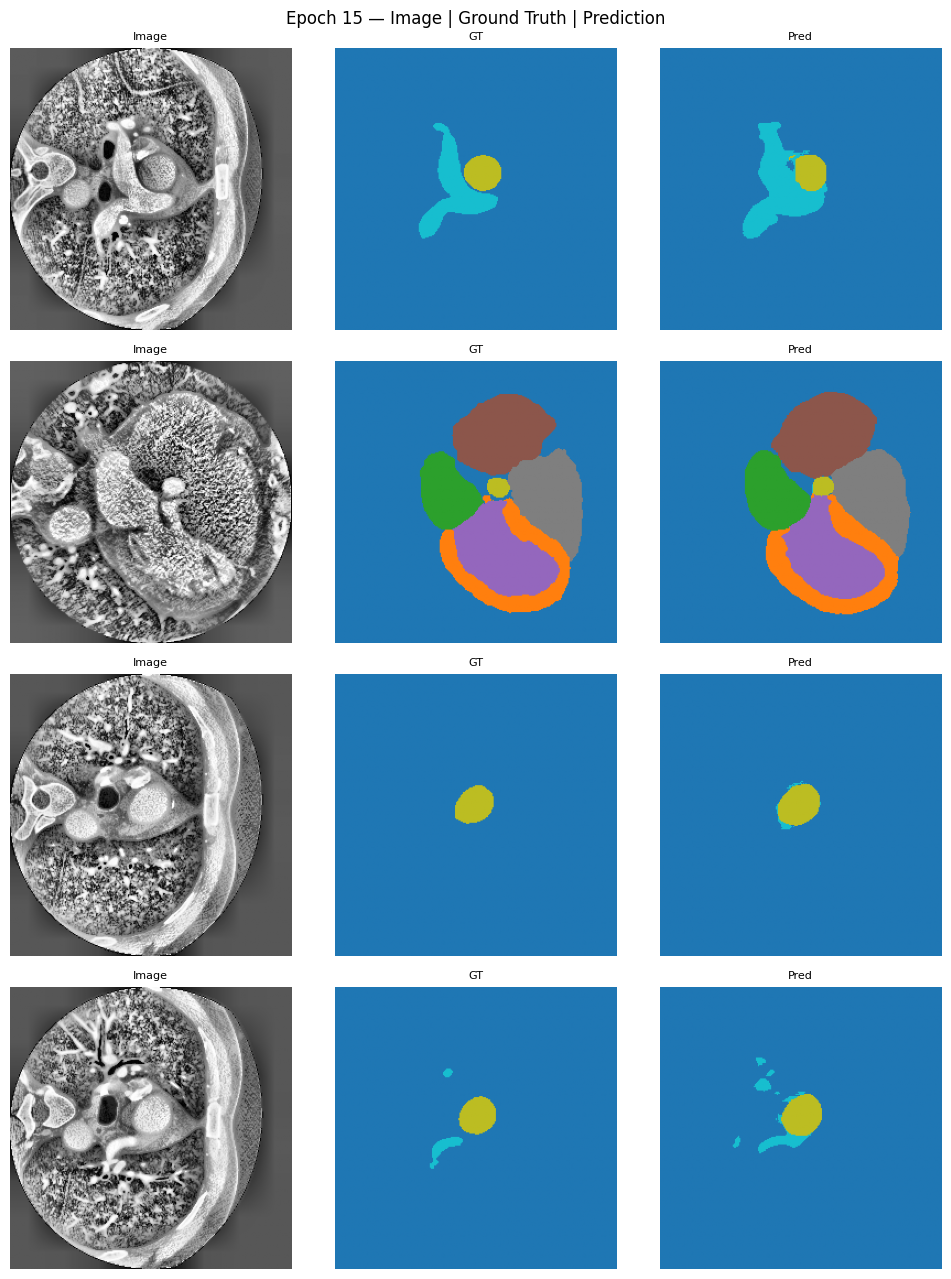


  Epoch 15 — Dice:
    MYO : 0.8575
    LA  : 0.9007
    LV  : 0.8115
    RA  : 0.7976
    RV  : 0.8292
    AA  : 0.9151
    PA  : 0.6484
    Mean: 0.8229

Epoch  16/30  train=0.2392  val=0.3942  lr=5.00e-05  patience=10
Early stopping at epoch 16
Checkpoint saved to /content/drive/MyDrive/Medical Imaging Project/checkpoints/best_efficientnet_ct_combined_loss_2026-03-31.pth


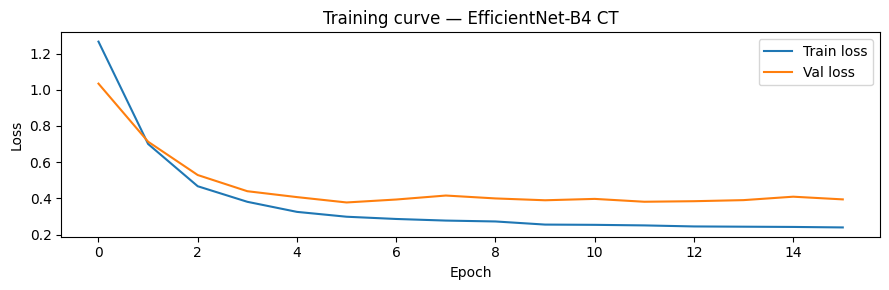

In [7]:
#  Training
import shutil

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

PREVIEW_IDXS  = random.sample(range(len(test_ds)), 4)
PREVIEW_EVERY = 5

def preview(epoch):
    model.eval()
    fig, axes = plt.subplots(4, 3, figsize=(10, 13))
    fig.suptitle(f'Epoch {epoch} - Image | Ground Truth | Prediction', fontsize=12)
    with torch.no_grad():
        for i, idx in enumerate(PREVIEW_IDXS):
            img_t, lbl_t = test_ds[idx]
            pred = model(img_t.unsqueeze(0).to(DEVICE)).argmax(dim=1).cpu().numpy()[0]
            img  = img_t.numpy()[0]
            lbl  = lbl_t.numpy()
            axes[i,0].imshow(img,  cmap='gray');                   axes[i,0].set_title('Image', fontsize=8); axes[i,0].axis('off')
            axes[i,1].imshow(lbl,  cmap='tab10', vmin=0, vmax=7); axes[i,1].set_title('GT',    fontsize=8); axes[i,1].axis('off')
            axes[i,2].imshow(pred, cmap='tab10', vmin=0, vmax=7); axes[i,2].set_title('Pred',  fontsize=8); axes[i,2].axis('off')
    plt.tight_layout(); plt.show()

    dice_scores = {c: [] for c in range(1, NUM_CLASSES)}
    with torch.no_grad():
        for idx in range(len(test_ds)):
            img_t, lbl_t = test_ds[idx]
            pred = model(img_t.unsqueeze(0).to(DEVICE)).argmax(dim=1).cpu().numpy()[0]
            lbl  = lbl_t.numpy()
            for c in range(1, NUM_CLASSES):
                gt_c, pred_c = lbl == c, pred == c
                if gt_c.sum() == 0: continue
                inter = (pred_c & gt_c).sum()
                denom = pred_c.sum() + gt_c.sum()
                if denom > 0: dice_scores[c].append(2 * inter / denom)
    print(f'\n  Epoch {epoch} - Dice:')
    mean_dice = []
    for c in range(1, NUM_CLASSES):
        d = np.nanmean(dice_scores[c]) if dice_scores[c] else float('nan')
        mean_dice.append(d)
        print(f'    {CLASS_NAMES[c]:<4}: {d:.4f}')
    print(f'    Mean: {np.nanmean(mean_dice):.4f}\n')


def run_epoch(loader, training):
    model.train() if training else model.eval()
    total_loss = 0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            loss = criterion(model(images), labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)


best_val_loss    = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(1, QUICK_EPOCHS + 1):
    train_loss = run_epoch(train_loader, training=True)
    val_loss   = run_epoch(val_loader,   training=False)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_NAME)
    else:
        patience_counter += 1

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:3d}/{QUICK_EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  lr={lr_now:.2e}  patience={patience_counter}')

    if epoch % PREVIEW_EVERY == 0:
        preview(epoch)

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

ckpt_dir = os.path.join(PROJECT_ROOT, 'checkpoints')
os.makedirs(ckpt_dir, exist_ok=True)
shutil.copy(CKPT_NAME, os.path.join(ckpt_dir, CKPT_NAME))
print(f'Checkpoint saved to {ckpt_dir}/{CKPT_NAME}')

plt.figure(figsize=(9, 3))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training curve - EfficientNet-B4 CT'); plt.legend()
plt.tight_layout(); plt.show()

In [7]:
#  Evaluation - Dice, Jaccard, ASD, Hausdorff Distance
ckpt_path = os.path.join(PROJECT_ROOT, 'checkpoints', CKPT_NAME)
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model.eval()

FOREGROUND = list(range(1, NUM_CLASSES))
results = {c: {'dice': [], 'jaccard': [], 'asd': [], 'hd': []} for c in FOREGROUND}

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating'):
        preds = model(images.to(DEVICE)).argmax(dim=1).cpu().numpy()[0]
        gt    = labels.numpy()[0]
        for c in FOREGROUND:
            pred_c, gt_c = preds == c, gt == c
            if gt_c.sum() == 0: continue
            results[c]['dice'].append(dice_binary(pred_c, gt_c))
            results[c]['jaccard'].append(jaccard(pred_c, gt_c))
            asd, hd = surface_distances(pred_c, gt_c)
            results[c]['asd'].append(asd)
            results[c]['hd'].append(hd)

print(f"\n{'Class':<6} {'Dice':>7} {'Jaccard':>9} {'ASD':>8} {'HD':>8}")
print('-' * 42)
all_dice, all_jac, all_asd, all_hd = [], [], [], []
for c in FOREGROUND:
    d = np.nanmean(results[c]['dice'])
    j = np.nanmean(results[c]['jaccard'])
    a = np.nanmean(results[c]['asd'])
    h = np.nanmean(results[c]['hd'])
    all_dice.append(d); all_jac.append(j)
    all_asd.append(a);  all_hd.append(h)
    print(f"{CLASS_NAMES[c]:<6} {d:>7.4f} {j:>9.4f} {a:>8.3f} {h:>8.3f}")
print('-' * 42)
print(f"{'Mean':<6} {np.nanmean(all_dice):>7.4f} {np.nanmean(all_jac):>9.4f} "
      f"{np.nanmean(all_asd):>8.3f} {np.nanmean(all_hd):>8.3f}")

Evaluating: 100%|██████████| 484/484 [00:35<00:00, 13.46it/s]


Class     Dice   Jaccard      ASD       HD
------------------------------------------
MYO     0.8312    0.7334    2.524   14.479
LA      0.8565    0.7727    2.966   11.300
LV      0.8252    0.7389    2.851    9.457
RA      0.7908    0.6913    4.438   14.861
RV      0.7753    0.6946    4.031   15.519
AA      0.8959    0.8344    1.703    8.038
PA      0.4970    0.3682   22.479   77.985
------------------------------------------
Mean    0.7817    0.6905    5.856   21.663


In [8]:
#  Evaluation including Background (Class 0)
ALL_CLASSES = list(range(NUM_CLASSES))
results_all = {c: {'dice': [], 'jaccard': [], 'asd': [], 'hd': []} for c in ALL_CLASSES}

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating (all classes)'):
        preds = model(images.to(DEVICE)).argmax(dim=1).cpu().numpy()[0]
        gt    = labels.numpy()[0]
        for c in ALL_CLASSES:
            pred_c, gt_c = preds == c, gt == c
            if gt_c.sum() == 0: continue
            results_all[c]['dice'].append(dice_binary(pred_c, gt_c))
            results_all[c]['jaccard'].append(jaccard(pred_c, gt_c))
            asd, hd = surface_distances(pred_c, gt_c)
            results_all[c]['asd'].append(asd)
            results_all[c]['hd'].append(hd)

print(f"\n{'Class':<6} {'Dice':>7} {'Jaccard':>9} {'ASD':>8} {'HD':>8}")
print('-' * 42)
all_dice, all_jac, all_asd, all_hd = [], [], [], []
for c in ALL_CLASSES:
    d = np.nanmean(results_all[c]['dice'])
    j = np.nanmean(results_all[c]['jaccard'])
    a = np.nanmean(results_all[c]['asd'])
    h = np.nanmean(results_all[c]['hd'])
    all_dice.append(d); all_jac.append(j)
    all_asd.append(a);  all_hd.append(h)
    print(f"{CLASS_NAMES[c]:<6} {d:>7.4f} {j:>9.4f} {a:>8.3f} {h:>8.3f}")
print('-' * 42)
print(f"{'Mean':<6} {np.nanmean(all_dice):>7.4f} {np.nanmean(all_jac):>9.4f} "
      f"{np.nanmean(all_asd):>8.3f} {np.nanmean(all_hd):>8.3f}")


Evaluating (all classes): 100%|██████████| 484/484 [00:37<00:00, 12.91it/s]


Class     Dice   Jaccard      ASD       HD
------------------------------------------
BG      0.9780    0.9570    2.030   31.675
MYO     0.8312    0.7334    2.524   14.479
LA      0.8565    0.7727    2.966   11.300
LV      0.8252    0.7389    2.851    9.457
RA      0.7908    0.6913    4.438   14.861
RV      0.7753    0.6946    4.031   15.519
AA      0.8959    0.8344    1.703    8.038
PA      0.4970    0.3682   22.479   77.985
------------------------------------------
Mean    0.8062    0.7238    5.378   22.914
